# Locally-Weighted Logistic Regression

Bài toán: với một query point $x$, dự đoán nhãn $y \in \{0, 1\}$.

Pipeline gồm 3 bước:

$$\text{Input: } X_{\text{train}}, y_{\text{train}}, x, \tau \xrightarrow{\text{Bước 1}} w^{(i)} \xrightarrow{\text{Bước 2}} \theta^* \xrightarrow{\text{Bước 3}} \hat{y}$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load data
X_train = np.loadtxt('data/x.dat')   # shape (69, 2)
y_train = np.loadtxt('data/y.dat')   # shape (69,)

---
## Bước 1 — Tính weights

Với mỗi training example $x^{(i)}$, tính weight dựa trên khoảng cách đến query point $x$:

$$w^{(i)} = \exp\!\left(-\frac{\|x - x^{(i)}\|^2}{2\tau^2}\right)$$

**Ý nghĩa:**
- $x^{(i)}$ càng gần $x$ → $w^{(i)}$ càng gần 1
- $x^{(i)}$ càng xa $x$ → $w^{(i)}$ càng gần 0
- $\tau$ (bandwidth) kiểm soát tốc độ weight giảm theo khoảng cách

**Cách tính trong NumPy:**

```
x - X_train → diff shape (69, 2)   # broadcasting: trừ x vào từng hàng
diff**2     → bình phương từng phần tử
sum(axis=1) → (69,)                # cộng theo cột, giữ nguyên hàng = ||x - x^(i)||^2
np.exp(...) → (69,)                # w^(i) cho mỗi training example
```

In [11]:
def compute_weights(X_train, x, tau):
    """
    Parameters
    ----------
    X_train : (m, 2)  training features
    x       : (2,)    query point
    tau     : float   bandwidth

    Returns
    -------
    w : (m,)  per-example weights
    """
    diff = x - X_train                    # (m, 2) — khoảng cách từng chiều
    sq_dist = np.sum(diff**2, axis=1)     # (m,)   — ||x - x^(i)||^2
    return np.exp(-sq_dist / (2 * tau**2))  # (m,)

---
## Bước 2 — Tối ưu $\ell(\theta)$ bằng Newton-Raphson

### 2a. Objective function

Maximize weighted regularised log-likelihood:

$$\ell(\theta) = -\frac{\lambda}{2}\theta^T\theta + \sum_{i=1}^{m} w^{(i)}\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1 - h_\theta(x^{(i)}))\right]$$

Trong đó $h_\theta(x^{(i)}) = \sigma(\theta^T x^{(i)}) = \dfrac{1}{1+e^{-\theta^T x^{(i)}}}$

### 2b. Newton-Raphson update rule

$$\theta := \theta - H^{-1}\nabla_\theta\ell(\theta)$$

**Gradient** (đề bài cho):

$$\nabla_\theta\ell(\theta) = X^T z - \lambda\theta, \qquad z_i = w^{(i)}(y^{(i)} - h_\theta(x^{(i)}))$$

**Hessian** (đề bài cho):

$$H = X^T D X - \lambda I, \qquad D_{ii} = -w^{(i)}h_\theta(x^{(i)})(1 - h_\theta(x^{(i)}))$$

**Lưu ý implement:** Thay vì tính $H^{-1}$ trực tiếp, giải hệ $H\delta = \nabla\ell(\theta)$ rồi update $\theta := \theta - \delta$ — chính xác và nhanh hơn.

In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def newton_raphson(X, y, w, lamb=1e-4, max_iter=100, tol=1e-6):
    """
    Parameters
    ----------
    X    : (m, 3)  design matrix với intercept column
    y    : (m,)    binary labels
    w    : (m,)    per-example weights
    lamb : float   regularisation coefficient

    Returns
    -------
    theta : (3,)  optimised parameters
    """
    theta = np.zeros(X.shape[1])       # khởi tạo theta = [0, 0, 0]

    for _ in range(max_iter):
        # h_theta(x^(i)) cho toàn bộ training set
        h = sigmoid(X @ theta)         # (m,)

        # Gradient
        z = w * (y - h)                # (m,)  residual có weight
        grad = X.T @ z - lamb * theta  # (3,)

        # Hessian — D chỉ lưu đường chéo dưới dạng vector
        d_diag = -w * h * (1 - h)          # (m,)
        H = (X * d_diag[:, None]).T @ X - lamb * np.eye(3)  # (3, 3)
        # X * d_diag[:, None] : nhân từng hàng i của X với d_diag[i] → DX
        # .T @ X              : (DX)^T X = X^T D X

        # Update: giải H*delta = grad thay vì tính H^{-1}
        delta = np.linalg.solve(H, grad)   # (3,)
        theta -= delta

        # Dừng sớm nếu delta đủ nhỏ
        if np.linalg.norm(delta) < tol:
            break

    return theta

---
## Bước 3 — Prediction

Sau khi có $\theta^*$ tối ưu:

$$\hat{y} = \mathbf{1}\{h_{\theta^*}(x) > 0.5\} = \mathbf{1}\{\sigma(\theta^{*T} x) > 0.5\}$$

In [13]:
def lwlr(X_train, y_train, x, tau, lamb=1e-4):
    """
    Locally-weighted logistic regression — predict label for query point x.

    Parameters
    ----------
    X_train : (m, 2)  raw features (không có intercept)
    y_train : (m,)    binary labels
    x       : (2,)    query point
    tau     : float   bandwidth

    Returns
    -------
    y_hat : int  in {0, 1}
    """
    # Thêm intercept column
    X = np.hstack([np.ones((X_train.shape[0], 1)), X_train])  # (m, 3)
    x_aug = np.concatenate([[1.0], x])                         # (3,)

    # Bước 1: weights
    w = compute_weights(X_train, x, tau)       # (m,)

    # Bước 2: tối ưu theta
    theta = newton_raphson(X, y_train, w, lamb)  # (3,)

    # Bước 3: predict
    prob = sigmoid(x_aug @ theta)
    return int(prob > 0.5)

---
## Phần (b) — Thí nghiệm bandwidth $\tau$

| $\tau$ | Behavior |
|--------|----------|
| Nhỏ (0.01) | Chỉ vài điểm gần nhất có ảnh hưởng → boundary cục bộ, dễ nhiễu |
| Vừa (0.1) | Cân bằng — boundary linh hoạt, bám cấu trúc data |
| Lớn (5.0) | Gần như mọi điểm có weight ≈ 1 → tiệm cận logistic regression thường |

**Kết luận:** Unweighted logistic regression tương ứng với $\tau \to \infty$.

Plotting tau=0.01...
Plotting tau=0.05...
Plotting tau=0.1...
Plotting tau=0.5...
Plotting tau=1.0...
Plotting tau=5.0...


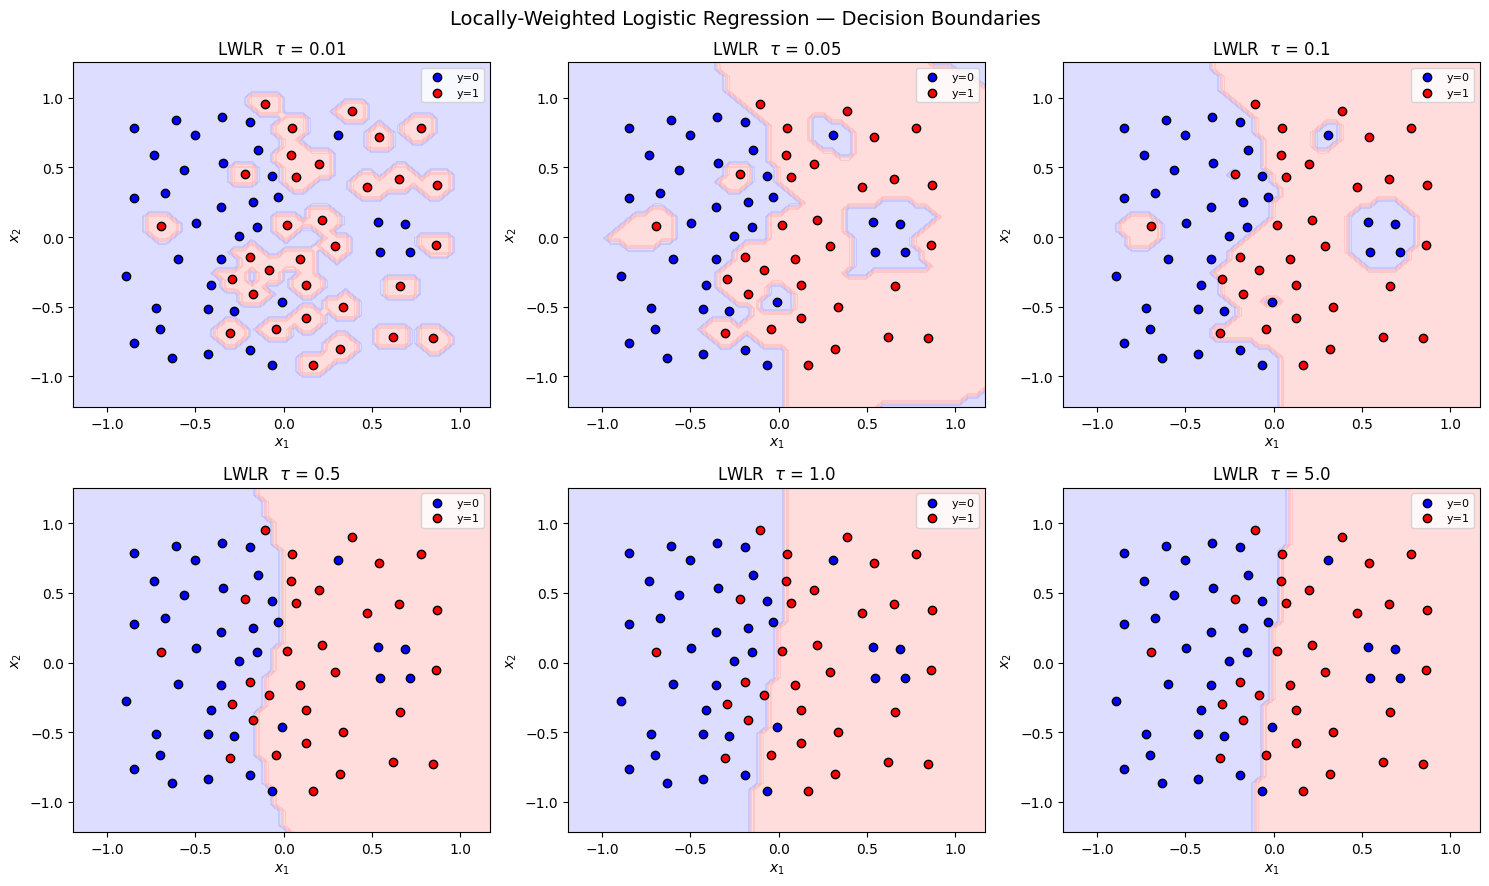

In [15]:
def plot_lwlr(X_train, y_train, tau, resolution=50, ax=None, lamb=1e-4):
    x1_min, x1_max = X_train[:, 0].min() - 0.3, X_train[:, 0].max() + 0.3
    x2_min, x2_max = X_train[:, 1].min() - 0.3, X_train[:, 1].max() + 0.3

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, resolution),
        np.linspace(x2_min, x2_max, resolution),
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]

    preds = np.array([lwlr(X_train, y_train, pt, tau, lamb) for pt in grid])
    Z = preds.reshape(xx1.shape)

    if ax is None:
        _, ax = plt.subplots()

    cmap_bg = ListedColormap(["#AAAAFF", "#FFAAAA"])
    ax.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               c='blue', edgecolors='k', label='y=0', zorder=3)
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               c='red', edgecolors='k', label='y=1', zorder=3)
    ax.set_title(f'LWLR  $\\tau$ = {tau}', fontsize=12)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.legend(fontsize=8)


# Plot tất cả tau values
tau_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Locally-Weighted Logistic Regression — Decision Boundaries', fontsize=14)

for ax, tau in zip(axes.ravel(), tau_values):
    print(f'Plotting tau={tau}...')
    plot_lwlr(X_train, y_train, tau, resolution=50, ax=ax)

plt.tight_layout()
plt.show()